## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn

from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

### Generate Data

#### For Binary Classification

In [2]:
X_orig, y_orig = make_moons(256, noise=0.1, random_state=42)

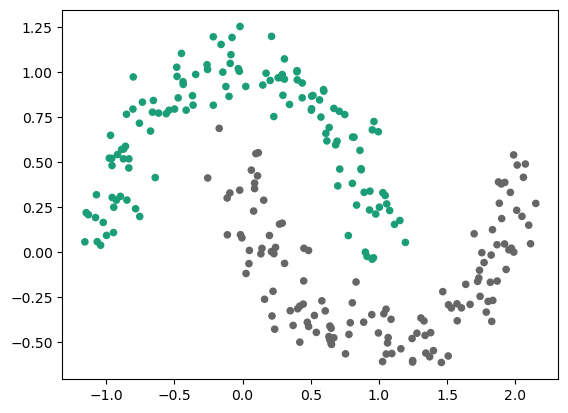

In [6]:
# This makes an independent copy (recommended in most cases)
X = torch.tensor(X_orig, dtype=torch.float32)
y = torch.tensor(y_orig, dtype=torch.long)


plt.scatter(*X.T, s = 20, c = y, cmap='Dark2');

## Section 1: Create a Model

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `model(X_input)` | Pass input `X_input` to a neuronal network named `model`. |
| `y_model = model(X_input)` | Pass input `X_input` to a neuronal network `model` and assign the output to a variable `y_model`. |
| `nn.ReLU()` | A rectified linear unit activation function.|
| `nn.Tanh()` | A hyperbolic tangent activation function.|
| `nn.Softmax()` | A softmax activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|

**Exercise**: Create a rectified linear unit activation function.

In [69]:
model = nn.ReLU()

**Exercise**: Create a hyperbolic tangent activation function.

In [ ]:
nn.Tanh()

**Exercise**: Create a sequence of layers with a rectified linear unit between them. The first layer should have two input features and 16 output features, the last layer should take in the 16 outputs from the first layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=16, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=16, out_features=2, bias=True)  <br>
)

**Hint**: nn.Sequential (see reference table).

In [ ]:
nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)

**Exercise**: Create sequence of three linear layers with one hyperbolic tangent activation function and one rectified linear unit between the first and the second linear layer, respectively. The first layer should have two input features and 32 output features, the next linear layer should have 32 input features and 32 output features, the last layer should take in the 32 outputs from the previous layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): Tanh()  <br>
  &nbsp;&nbsp;(0): Linear(in_features=32, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=32, out_features=2, bias=True)  <br>
)

**Hint**: nn.Sequential (see reference table).

In [71]:
nn.Sequential(
    nn.Linear(2,32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.ReLU(),
    nn.Linear(16,2)
)

Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)

## Section 2: Binary Classification with a Neural Network Model 

| Code | Description |
| --- | --- |
| `` | duh |

In [47]:
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1),
    nn.Sigmoid(),
)
model

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): Sigmoid()
)

In [51]:
model = nn.Linear(2,1)

from torch import optim

optimizer = optim.SGD(model.parameters(), lr=0.1)

for step in range(100):
    
#model(X)

tensor([[ 0.6682],
        [ 0.1559],
        [-1.0607],
        [ 0.5868],
        [-1.3583],
        [ 0.0815],
        [ 0.7628],
        [-0.1416],
        [ 0.0779],
        [-0.3356],
        [ 0.1035],
        [ 0.7149],
        [ 0.7640],
        [ 0.6464],
        [-0.7133],
        [-0.8407],
        [ 0.3247],
        [-0.1044],
        [-1.3692],
        [-0.1578],
        [ 0.7735],
        [-0.1965],
        [-1.1989],
        [-0.4393],
        [-0.1458],
        [-1.2295],
        [ 0.6936],
        [ 0.6552],
        [ 0.0485],
        [-0.1844],
        [ 0.1700],
        [-1.4058],
        [-0.3758],
        [ 0.3663],
        [ 0.6166],
        [-0.2199],
        [-1.2157],
        [-0.0671],
        [-0.9626],
        [-0.7099],
        [ 0.3959],
        [ 0.0550],
        [ 0.8584],
        [ 0.0831],
        [-0.6022],
        [-1.0724],
        [-0.1164],
        [-0.9620],
        [ 0.5771],
        [ 0.5931],
        [ 0.0646],
        [-0.3021],
        [-0.

The output of the network is a score for each class that reflects the networks belief that a data point corresponds to a given class. This is not the same as a class label. To get the output in the form of a class guess by the network, we have to determine which class the network thinks that a data point is most likely to belong to using the output scores.

| Code | Description |
| --- | --- |
| `torch.argmax(x, dim=1)` | Finds the index at which the tensor `x` has the highest value along its first dimension. |
| `a == b` | Compares each element of the tensors (or arrays) `a` and `b` and returns a tensor of boolean (`True` or `False`) values indicating which elements are the same (`True`) and different (`False`). |
| `(a == b).sum()` or `torch.sum(a == b)`| Sums all elements where the condition `a == b` is `True`. `True` is counted as 1, `False` as 0. |
| `(a == b).sum() / len(a)` | Calculates proportion of elements in `a` where the element is equal to the corresponding element in `b`.|

Run the cell below to create a network, select a subset of the data, and pass this subset through the network to get an output `y_net`.